# 

# Data Exploration

## Overview

This notebook explores the Bonn Furniture Styles Dataset and prepares the dataset foundation for the furniture sketch classification pipeline.

The goal of this notebook is to examine the dataset structure, class distributions, image characteristics, and predefined train/validation/test splits that will be used in the following notebooks.

**Dataset:** Bonn Furniture Styles Dataset - Aggarwal et al. (2018)  
**Original categories:** beds, chairs, dressers, lamps, sofas, tables  
**Selected classes:** beds, chairs, dressers, sofas, tables  
**Excluded class:** lamps  
**Images after excluding lamps:** 57,682  
**Split:** predefined train / validation / test split files  
**Prototype subset:** 500 images per selected class

## Introduction

The goal of this project is to build a classical machine learning pipeline for recognizing furniture categories from sketch-like edge images.

Instead of using hand-drawn sketches, this project starts from real furniture images and automatically converts them into sketch-like representations using edge detection. These generated sketches will later be used for feature extraction and classification.

This first notebook focuses on understanding the dataset before any modeling is performed. The main tasks are:

- load the predefined dataset split files;
- exclude the `lamps` category from the current project scope;
- inspect the distribution of the selected furniture categories;
- check for duplicated image paths;
- verify that the dataset structure is suitable for the next stages of the pipeline.

The selected five categories are `beds`, `chairs`, `dressers`, `sofas`, and `tables`. These categories are used as the foundation for the first prototype of the furniture sketch classifier.

## Setup and Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import sys
sys.path.append("..")
from src import utils

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


## Dataset Overview

In [2]:
df = utils.load_dataset_splits()
print(f"Total images loaded: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Found 1 duplicated image path(s). Removing duplicates...
Total images loaded: 57682
Columns: ['split', 'path', 'relative_path', 'category', 'class_name', 'style']


In [3]:
print(f"Dataset shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes)

Dataset shape: (57682, 6)

Column types:
split            object
path             object
relative_path    object
category         object
class_name       object
style            object
dtype: object


In [4]:
df.head()

,split,path,relative_path,category,class_name,style
0,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/dressers/Transitional/6609transitional-d...,dressers,dresser,Transitional
1,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/dressers/Contemporary/625contemporary-dr...,dressers,dresser,Contemporary
2,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/chairs/Midcentury/18157midcentury-armcha...,chairs,chair,Midcentury
3,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/tables/Scandinavian/25scandinavian-coffe...,tables,table,Scandinavian
4,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/dressers/Contemporary/944contemporary-dr...,dressers,dresser,Contemporary


### Duplicate Path Check and Observation

One duplicated image path was identified in the predefined split files: `houzz/dressers/Asian/dresser.jpg`. The duplicate is removed before prototype sampling to avoid counting the same image twice.

After excluding lamps and removing the duplicate, the dataset contains **57,682 unique images** across five furniture categories.

The dataset is imbalanced: `chairs` and `tables` contain significantly more images than `sofas`. The first prototype therefore uses a balanced subset with an equal number of images per class.

Predefined train, validation, and test splits are used as provided, keeping the workflow reproducible and consistent with the original dataset structure.

## Prototype Sampling

The full selected dataset contains 57,682 images, which is larger than needed for the first pipeline test. To make debugging faster, the first prototype uses a balanced subset of 500 images per class.

The subset preserves the predefined train, validation, and test splits:

- 350 train images per class
- 75 validation images per class
- 75 test images per class

This gives 2,500 images in total.

In [5]:
df_proto = utils.sample_prototype_subset(df)

print(f"Prototype subset: {len(df_proto)} images")

print("\nClass distribution:")
print(df_proto["category"].value_counts())

print("\nSplit distribution:")
print(df_proto["split"].value_counts())

print("\nSplit x class distribution:")
display(pd.crosstab(df_proto["split"], df_proto["category"]))

Prototype subset: 2500 images

Class distribution:
category
tables      500
sofas       500
dressers    500
chairs      500
beds        500
Name: count, dtype: int64

Split distribution:
split
train    1750
test      375
val       375
Name: count, dtype: int64

Split x class distribution:


category,beds,chairs,dressers,sofas,tables
split,,,,,
test,75,75,75,75,75
train,350,350,350,350,350
val,75,75,75,75,75


The prototype subset contains **2,500 images** in total, with **500 images per furniture category**. Sampling was performed separately inside each predefined split, so the original train / validation / test structure is preserved.

This balanced subset will be used first to test the complete pipeline before scaling to a larger dataset.

In [6]:
prototype_path = utils.SPLITS_DIR / "prototype_500_per_class.csv"
df_proto.to_csv(prototype_path, index=False)
print(f"Prototype metadata saved to: {prototype_path}")
print(f"File size: {prototype_path.stat().st_size / 1024:.1f} KB")

Prototype metadata saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\data\splits\prototype_500_per_class.csv
File size: 714.4 KB


The prototype metadata file was saved locally and will be used by the next notebooks. The file contains the selected image paths, labels, styles, and predefined split information for the balanced 500-images-per-class prototype dataset.

The dataset files are not tracked in Git because they can be regenerated from the original Bonn split files.

## Class Distribution

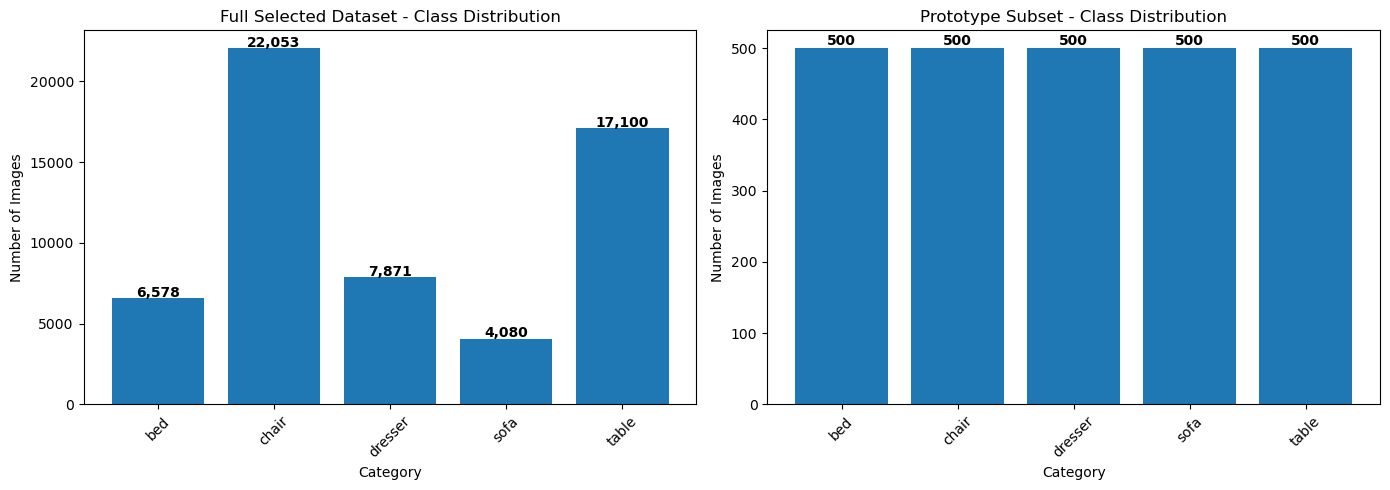

Figure saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\figures\class_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full dataset distribution
counts_full = df["class_name"].value_counts().sort_index()

axes[0].bar(counts_full.index, counts_full.values)
axes[0].set_title("Full Selected Dataset - Class Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis="x", rotation=45)

for i, count in enumerate(counts_full.values):
    axes[0].text(i, count + 100, f"{count:,}", ha="center", fontweight="bold")

# Prototype distribution
counts_proto = df_proto["class_name"].value_counts().sort_index()

axes[1].bar(counts_proto.index, counts_proto.values)
axes[1].set_title("Prototype Subset - Class Distribution")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Number of Images")
axes[1].tick_params(axis="x", rotation=45)

for i, count in enumerate(counts_proto.values):
    axes[1].text(i, count + 5, f"{count:,}", ha="center", fontweight="bold")

plt.tight_layout()

fig_path = utils.FIGURES_DIR / "class_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {fig_path}")

The full selected dataset is imbalanced. `chair` and `table` have the largest number of images, while `sofa` has the smallest number of images.

The prototype subset removes this imbalance by sampling exactly **500 images per class**. This balanced subset is used for the first end-to-end pipeline test so that the initial model evaluation is easier to interpret and not dominated by the largest classes.

## Sample Visualization

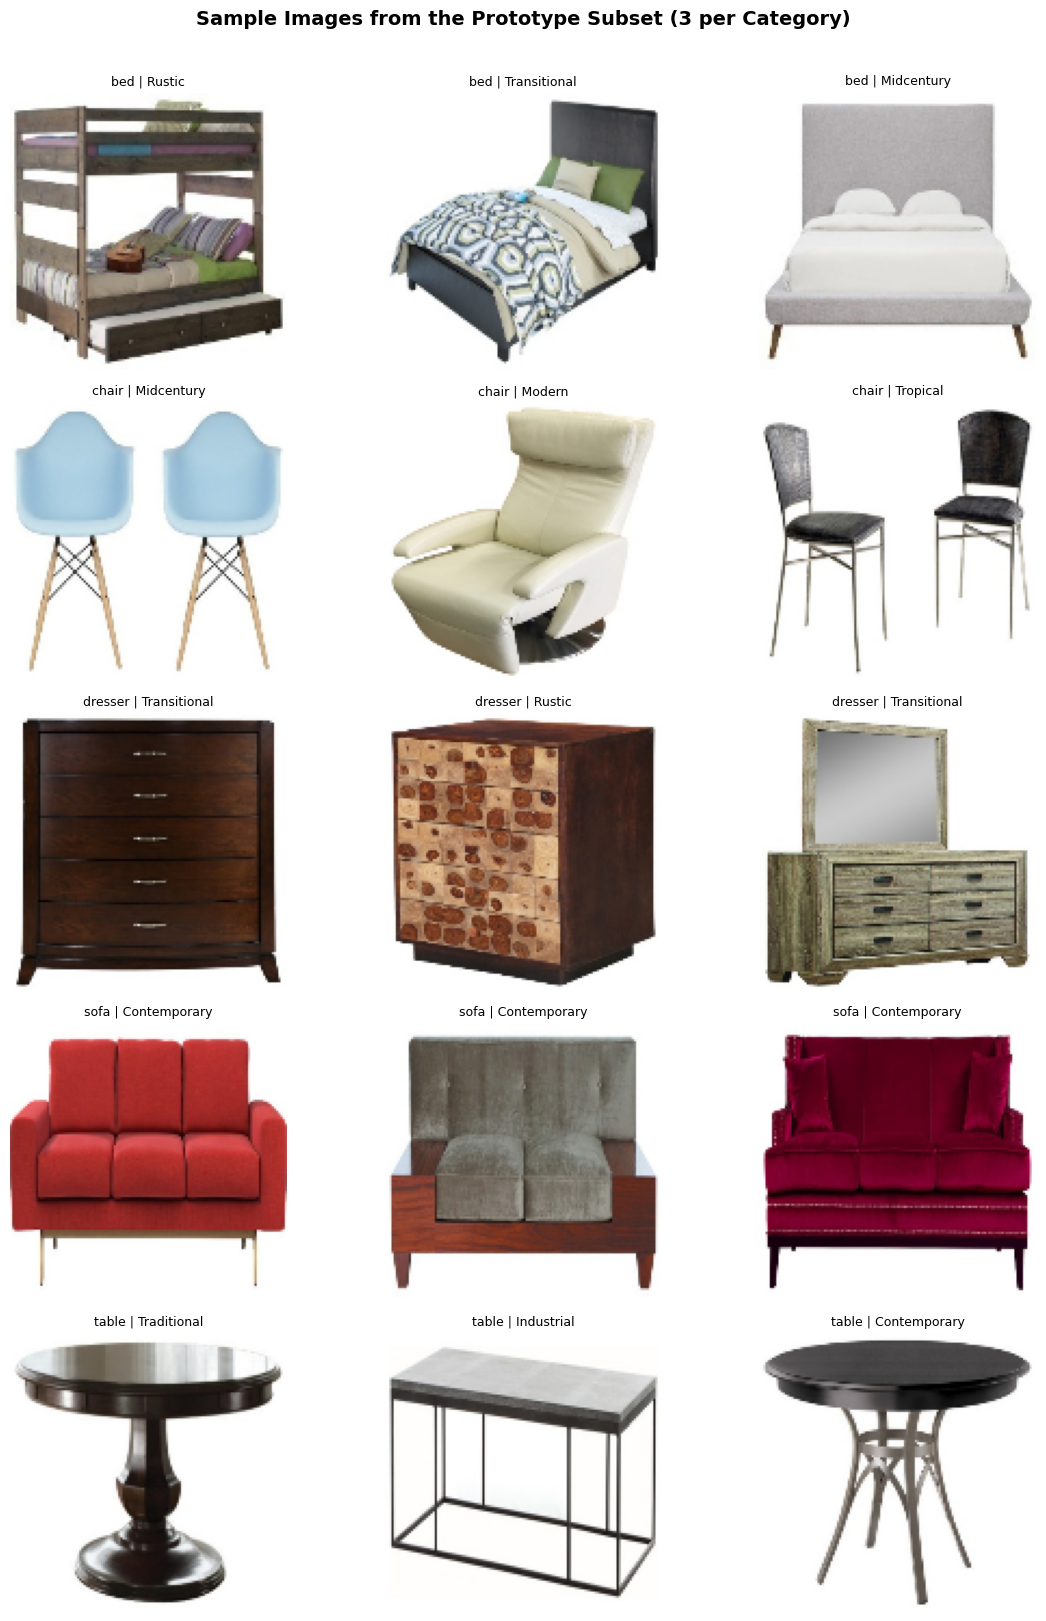

Figure saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\figures\sample_images.png


In [8]:
fig, axes = plt.subplots(5, 3, figsize=(12, 16))

for row, category in enumerate(utils.SELECTED_CLASSES):
    samples = df_proto[df_proto["category"] == category].sample(
        3, random_state=utils.RANDOM_STATE
    )

    for col, (_, row_data) in enumerate(samples.iterrows()):
        img = utils.load_image(row_data["path"])

        if img is not None:
            axes[row, col].imshow(img)
            axes[row, col].set_title(
                f"{row_data['class_name']} | {row_data['style']}",
                fontsize=9
            )
        else:
            axes[row, col].text(
                0.5, 0.5, "Image\nnot loaded",
                ha="center", va="center", fontsize=8
            )

        axes[row, col].axis("off")

# for category in utils.SELECTED_CLASSES:
    # samples = df_proto[df_proto["category"] == category].sample(
        # 3, random_state=utils.RANDOM_STATE
    # )
    # print(category)
    # display(samples[["relative_path", "category", "class_name", "style"]])

plt.suptitle(
    "Sample Images from the Prototype Subset (3 per Category)",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

fig_path = utils.FIGURES_DIR / "sample_images.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {fig_path}")

The sample visualization shows that most images in the prototype subset are clean product-style furniture images with simple backgrounds. The examples also show visual diversity inside each class, including different styles, shapes, materials, and viewing angles.

During visual inspection, one clearly incorrect image was found in the `chair` category. It did not represent furniture and was removed from the prototype subset using a small manual blacklist.

The `bed` category also contains different bed subtypes, including platform beds, canopy beds, daybeds, and bunk beds. Although bunk beds are visually different from standard beds, they are kept because they still belong to the broader furniture category `bed`. This creates intra-class variation, where images from the same category can have different shapes and edge structures.

This confirms that the dataset contains both useful visual diversity and some web-scraped noise. The first prototype keeps the cleaning process minimal, while later versions can add more systematic image quality filtering.

## Image Quality Analysis

The Bonn Furniture Styles Dataset is mostly composed of clean product-style furniture images, but visual inspection shows that the dataset is not perfectly clean. Since the images were collected from the web, some noise is expected.

For this project, image quality matters because edge detection can amplify unwanted visual elements. Background objects, text, multiple furniture items, or incorrect labels can create extra edges and may affect HOG features and classification performance.

This section performs a lightweight quality check before moving to sketch generation.

In [9]:
missing_paths = df_proto[~df_proto["path"].apply(lambda p: p.exists())]

print(f"Missing image files: {len(missing_paths)}")
missing_paths.head()

Missing image files: 0


,split,path,relative_path,category,class_name,style


In [10]:
failed_images = []

for _, row in df_proto.iterrows():
    img = utils.load_image(row["path"])
    if img is None:
        failed_images.append(row["relative_path"])

print(f"Images that failed to load: {len(failed_images)}")
failed_images[:10]

Images that failed to load: 0


[]

In [16]:
image_info = []

for _, row in df_proto.iterrows():
    try:
        with Image.open(row["path"]) as img:
            width, height = img.size
            image_info.append({
                "relative_path": row["relative_path"],
                "category": row["category"],
                "width": width,
                "height": height,
                "mode": img.mode,
                "aspect_ratio": width / height
            })
    except Exception:
        image_info.append({
            "relative_path": row["relative_path"],
            "category": row["category"],
            "width": None,
            "height": None,
            "mode": None,
            "aspect_ratio": None
        })

image_info_df = pd.DataFrame(image_info)

image_info_df.describe()

,width,height,aspect_ratio
count,2500.000000,2500.000000,2500.0
mean,325.001600,325.001600,1.0
std,50.258221,50.258221,0.0
min,224.000000,224.000000,1.0
25%,350.000000,350.000000,1.0
50%,350.000000,350.000000,1.0
75%,350.000000,350.000000,1.0
max,350.000000,350.000000,1.0


In [17]:
print(image_info_df["mode"].value_counts(dropna=False))

mode
RGB    2500
Name: count, dtype: int64


In [18]:
print(image_info_df["width"].value_counts().sort_index())

width
224     496
350    2004
Name: count, dtype: int64


The prototype subset passed the basic technical quality checks. All selected image paths exist, and all images can be loaded successfully.

All prototype images are in RGB mode and have a square aspect ratio of 1.0. Most images are 350×350 pixels, while a smaller group is 224×224 pixels. This size variation is not a problem because all images will be resized to a fixed resolution before sketch generation and feature extraction.

These checks confirm that the prototype subset can be processed automatically in the next notebook. However, technical validity does not guarantee semantic correctness, so some web-scraped noise may still remain.

## Split Verification

In [19]:
# Verify no image appears in more than one split (no leakage)
paths_per_split = df_proto.groupby("relative_path")["split"].nunique()
n_cross_split = int((paths_per_split > 1).sum())
print(f"Images assigned to more than one split: {n_cross_split}")

Images assigned to more than one split: 0


In [20]:
split_verification = pd.crosstab(df_proto["split"], df_proto["class_name"])
split_verification = split_verification.loc[["train", "val", "test"]]
split_verification

class_name,bed,chair,dresser,sofa,table
split,,,,,
train,350,350,350,350,350
val,75,75,75,75,75
test,75,75,75,75,75


No image was assigned to more than one split, confirming that the train, validation, and test sets are disjoint and that no data leakage was introduced by prototype sampling or duplicate removal.

The per-split, per-class counts are uniform: 350 training images, 75 validation images, and 75 test images for each of the five categories. This balanced structure removes class frequency as a major confounding factor, making later model comparisons easier to interpret.

## Summary and Observations

This notebook prepared the dataset foundation for the furniture sketch classification pipeline.

Main outcomes:

- The Bonn Furniture Styles Dataset was loaded from the predefined split files. The `lamps` category was excluded, and one duplicated image path was removed.
- The selected five-class dataset contains **57,682 unique images** across `bed`, `chair`, `dresser`, `sofa`, and `table`.
- A balanced prototype subset of **500 images per class** (**2,500 total**) was sampled, preserving the predefined train / validation / test structure.
- All prototype image paths exist and all images load successfully.
- The images are `RGB` and square-sized at either 350×350 or 224×224, so fixed-size resizing introduces no aspect-ratio distortion.
- No image appears in more than one split, confirming that the splits are disjoint and free of leakage.

Two limitations are carried forward. Technical validity does not guarantee semantic correctness, so some web-scraped noise may remain beyond the single mislabeled image already removed. The `bed` category also mixes subtypes such as platform beds, canopy beds, daybeds, and bunk beds, creating intra-class variation in shape and edge structure. Both limitations are acceptable for a first prototype and can be filtered more systematically in later iterations if they affect performance.

The dataset is suitable for the next stage. The next notebook, `02_sketch_generation.ipynb`, will use the prototype metadata to generate Canny edge sketches and compare basic edge-detection methods.